# Data

In [1]:
with open("The Adventures of Sherlock Holmes.txt", 'r') as text_file:
    text = text_file.read()[1474:] # remove metadata

In [2]:
len(text)

580127

In [3]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
VOCAB_SIZE = len(set(text))

In [5]:
stoi = {k: v for v, k in enumerate(set(text))}
itos = {v: k for k, v in stoi.items()}

In [6]:
encode = lambda word: [stoi[c] for c in word]
decode = lambda cypher: "".join(itos[c] for c in cypher)

In [7]:
encoded_text = encode(text)

In [8]:
def train_valid_split(x, ratio):
    a = int(ratio * len(x))
    return x[:a], x[a:]

train_set, valid_set = train_valid_split(encoded_text, ratio=0.9)

In [9]:
from enum import Enum, auto

torch.manual_seed(42)

class SetType(Enum):
    TRAIN = auto()
    VALID = auto()

def get_batch(split: SetType, context_len: int, batch_size: int):
    data_set = train_set if split == SetType.TRAIN else valid_set
    max_rand = len(data_set) - context_len - 1
    offsets = torch.randint(max_rand, size=(batch_size, ))
    x = [data_set[offset:offset+context_len] for offset in offsets]
    y = [data_set[offset+1:offset+context_len+1] for offset in offsets]
    return torch.tensor(x), torch.tensor(y)

# Modules

In [10]:
import torch.nn.functional as F
from torch import nn

In [11]:
class AttentionHead(nn.Module):
    def __init__(
        self,
        emb_size: int,
        head_size: int,
        context_len: int,
    ) -> None:
        super().__init__()
        self.head_size = head_size
        self.querries = nn.Linear(emb_size, head_size, bias=False)
        self.keys = nn.Linear(emb_size, head_size, bias=False)
        self.values = nn.Linear(emb_size, head_size, bias=False)
        self.register_buffer("mask", torch.tril(torch.ones(context_len, context_len)))

    def forward(self, x):
        T = x.shape[1]
        q = self.querries(x)
        k = self.keys(x)
        v = self.values(x)
        w = q @ k.transpose(-2, -1) * self.head_size ** (-1/2)
        attention = w.masked_fill(self.mask[:T, :T] == 0, float("-inf")) # type: ignore
        self.out = F.softmax(attention, dim=-1) @ v
        return self.out

In [12]:
class MultiHeadAttention(nn.Module):
    def __init__(
        self,
        num_heads: int,
        emb_size: int,
        context_len: int,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()
        head_size = emb_size // num_heads
        self.heads = nn.ModuleList(
            AttentionHead(emb_size, head_size, context_len) for _ in range(num_heads)
        )
        self.projection_layer = nn.Linear(num_heads * head_size, emb_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = torch.cat([head(x) for head in self.heads], dim=-1)
        x = self.projection_layer(x)
        self.out = self.dropout(x)
        return self.out

In [13]:
class FeedForward(nn.Module):
    def __init__(self, emb_size: int, mid_layer_factor: int = 4, dropout: float = 0.2) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(emb_size, mid_layer_factor * emb_size),
            nn.GELU(),
            nn.Linear(mid_layer_factor * emb_size, emb_size),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.layers(x)

In [14]:
class AttentionBlock(nn.Module):
    def __init__(
        self,
        emb_size: int,
        num_heads: int,
        context_len: int,
    ) -> None:
        super().__init__()
        self.sa_heads = MultiHeadAttention(num_heads, emb_size, context_len)
        self.feedforward = FeedForward(emb_size)
        self.layer_norm_preheads = nn.LayerNorm(emb_size)
        self.layer_norm_postheads = nn.LayerNorm(emb_size)

    def forward(self, x):
        # skip connections
        x = x + self.sa_heads(self.layer_norm_preheads(x))
        x = x + self.feedforward(self.layer_norm_postheads(x))
        return x

In [15]:
class Model(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        emb_size: int,
        context_len: int,
        num_heads: int,
        num_layers: int,
    ) -> None:
        super().__init__()
        self.context_len = context_len
        self.tok_embeddings = nn.Embedding(vocab_size, emb_size)
        self.pos_embeddings = nn.Embedding(context_len, emb_size)
        self.flow = nn.Sequential(*[AttentionBlock(emb_size, num_heads, context_len) for _ in range(num_layers)])
        self.layer_norm = nn.LayerNorm(emb_size)
        self.logits_layer = nn.Linear(emb_size, vocab_size)

    def forward(self, x):
        tok_emb = self.tok_embeddings(x)
        pos_emb = self.pos_embeddings(torch.arange(self.context_len, device=device))
        x = tok_emb + pos_emb
        x = self.flow(x)
        x = self.layer_norm(x)
        return self.logits_layer(x)

In [16]:
CONTEXT_LEN = 256
BATCH_SIZE = 64
EMB_SIZE = 386
NUM_HEADS = 6
NUM_LAYERS = 4

In [17]:
model = Model(
    VOCAB_SIZE,
    EMB_SIZE,
    CONTEXT_LEN,
    NUM_HEADS,
    NUM_LAYERS,
).to(device=device)

In [18]:
@torch.no_grad()
def avg_train_valid_loss(model, eval_iters, context_len, batch_size):
    out = {}
    model.eval()
    for split in (SetType.TRAIN, SetType.VALID):
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, context_len, batch_size)
            X = X.to(device=device)
            Y = Y.to(device=device)
            logits = model(X)
            B, T, C = logits.shape
            losses = F.cross_entropy(logits.view(B * T, C), Y.view(B * T))
        out[split] = losses.mean()
    model.train()
    return out

In [19]:
EPOCHS = 5000
LEARNING_RATE = 3e-4
EVAL_INTERVAL = 500
EVAL_ITERS = 10

optimizer = torch.optim.AdamW(model.parameters(), LEARNING_RATE)

lossi = []

for epoch in range(EPOCHS):
    X_train, Y_train = get_batch(SetType.TRAIN, CONTEXT_LEN, BATCH_SIZE)
    X_train = X_train.to(device=device)
    Y_train = Y_train.to(device=device)
    logits = model(X_train)
    B, T, C = logits.shape
    loss = F.cross_entropy(logits.view(B * T, C), Y_train.view(B * T))
    lossi.append(loss.item())
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    if epoch % EVAL_INTERVAL == 0:
        losses = avg_train_valid_loss(model, EVAL_ITERS, CONTEXT_LEN, BATCH_SIZE)
        print(f"{epoch:>6}:{EPOCHS} {losses}")

     0:5000 {<SetType.TRAIN: 1>: tensor(4.1763, device='cuda:0'), <SetType.VALID: 2>: tensor(4.1869, device='cuda:0')}
   500:5000 {<SetType.TRAIN: 1>: tensor(1.8700, device='cuda:0'), <SetType.VALID: 2>: tensor(2.0846, device='cuda:0')}
  1000:5000 {<SetType.TRAIN: 1>: tensor(1.4711, device='cuda:0'), <SetType.VALID: 2>: tensor(1.8972, device='cuda:0')}
  1500:5000 {<SetType.TRAIN: 1>: tensor(1.2511, device='cuda:0'), <SetType.VALID: 2>: tensor(1.6838, device='cuda:0')}
  2000:5000 {<SetType.TRAIN: 1>: tensor(1.1611, device='cuda:0'), <SetType.VALID: 2>: tensor(1.5793, device='cuda:0')}
  2500:5000 {<SetType.TRAIN: 1>: tensor(1.0561, device='cuda:0'), <SetType.VALID: 2>: tensor(1.6891, device='cuda:0')}
  3000:5000 {<SetType.TRAIN: 1>: tensor(0.9629, device='cuda:0'), <SetType.VALID: 2>: tensor(1.6820, device='cuda:0')}
  3500:5000 {<SetType.TRAIN: 1>: tensor(0.8920, device='cuda:0'), <SetType.VALID: 2>: tensor(1.7053, device='cuda:0')}
  4000:5000 {<SetType.TRAIN: 1>: tensor(0.8247, 

In [20]:
torch.save(model.state_dict(), "model.pt")

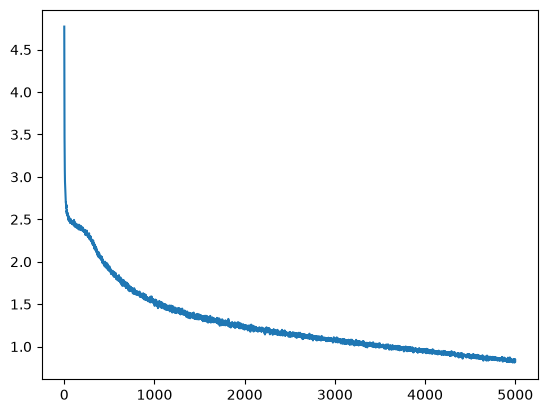

In [21]:
import matplotlib.pyplot as plt

plt.plot(range(EPOCHS), lossi)

In [ ]:
def generate(model, idx, max_new_tokens):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -CONTEXT_LEN:]
        logits = model(idx_cond)
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [24]:
context = torch.zeros((1, CONTEXT_LEN), dtype=torch.long, device=device)
generated = generate(model, context, max_new_tokens=2000)
print(decode(generated[0, CONTEXT_LEN:].tolist()))

. the
Le. Gompans were about tramm. Slazard up and bend which hat, and what
there sleeps retains a scertain, bill more repreated as perfect than to the Boscombe
than Flora and counsider and the scrap of some loaths light upon what
I should not call to-morrow. I wish to step threaten the coroner was
back.
Then closed his turned to his chair as to showly clapped over his biok to
two returned over his heads. You see, Mr. Holder, perhaps you have don’t
post. I shall be net engaging to a cry 4 pendicelectors’ raced to his
ruise men was back—
Hore good-night, smoked with flace. His speech, hand, gaped den by into
visitor between the windows of the Bridge, and he question aware onsan
_ worth which comes may have had cut up, and a long before paidint,
the manteetal spired glimpse of the price. Insed, all that very smiled even
goef Ireness to set to put the heelless by the couns depreseries, or
the night steel between the business. A countband, where we are at which next
dailing-haped brother t